In [1]:
import numpy as np
import torch
import pandas as pd
import joblib
import os
import datetime
import seaborn as sns
import time
import tracemalloc
import statistics
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import StandardScaler

c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Variáveis de Ambiente e Configuração de Caminhos
___________

**O que esta célula faz:**
Define os caminhos dos arquivos de dados (treino/teste), os arquivos de *embeddings* pré-processados e o modelo pré-treinado do BERT que será utilizado no projeto.

**O que você precisa fazer para funcionar:**
1. **Fazer o upload dos arquivos:** Certifique-se de enviar os seus arquivos CSV para o ambiente (ex: Google Colab) ou salvar no seu repositório local.
2. **Atualizar os caminhos:** Substitua as strings nos caminhos abaixo pelos caminhos reais onde seus arquivos estão salvos no seu computador ou no servidor:
   * `DATA_PATH_TRAIN`: Caminho do seu arquivo CSV de treino/geral.
   * `DATA_PATH_TEST`: Caminho do seu arquivo CSV de teste.
   * `MODEL_NAME`: Nome do modelo HuggingFace (padrão: BERTimbau).
   * `DATA_EMBEDDINGS_PATH`: Onde salvar/carregar os embeddings de treino gerados pelo BERT.
   * `DATA_EMBEDDINGS_TEST`: Onde salvar/carregar os embeddings de teste gerados pelo BERT.

In [2]:
DATA_PATH_TEST = '../../training_data/dataset.csv'
DATA_PATH_TRAIN = '../../training_data/dataset_treino.csv'
MODEL_NAME = 'neuralmind/bert-base-portuguese-cased'
DATA_EMBEDDINGS_PATH = '../data_bert_train.npz'
DATA_EMBEDDINGS_TEST = '../data_bert_test.npz'

### Processamento e Extração de Embeddings com BERT
___
**O que esta célula faz:**
1. **Carregamento e Configuração:** Lê o arquivo CSV de entrada, carrega o modelo BERT pré-treinado e configura o dispositivo de execução (GPU ou CPU).
2. **Divisão de Textos (Chunking):** A função `chunk_text_by_tokens` divide textos longos que ultrapassam o limite do BERT (128 tokens) em pedaços menores com sobreposição (*overlap*).
3. **Extração de Vetores:** Gera o vetor numérico (*embedding* do token `[CLS]`) para cada fragmento e calcula a média deles (`np.mean`), resultando em uma representação única por documento.
4. **concatenação dos dados:** Coleta os outros dados do csv e concatena em um unico eixo junto dos embedding
5. **Exportação dos Resultados:** Compacta e salva os vetores $X$ e os rótulos $y$ no arquivo binário `data_bert_test.npz`.

**O que fazer para funcionar:**
* Certifique-se de ter executado as células anteriores que carregam as bibliotecas (`pandas`, `numpy`, `torch`, `transformers`) e definem as variáveis de ambiente (`DATA_PATH`, `MODEL_NAME`).
* **Dica de Desempenho:** Se estiver no Google Colab, ative a GPU em *Ambiente de execução -> Alterar o tipo de ambiente de execução -> GPU* para acelerar o processamento do BERT.

In [ ]:
df = pd.read_csv(DATA_PATH_TEST)
sentences = df["text"].astype(str).tolist()
labels = df["label"].values

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME).to(device)


def chunk_text_by_tokens(text, max_tokens=128, overlap=20):
    tokens = tokenizer.encode(text, add_special_tokens=False)

    if len(tokens) <= max_tokens:
        return [text]

    chunks = []
    stride = max_tokens - overlap
    for i in range(0, len(tokens), stride):
        chunk_tokens = tokens[i : i + max_tokens]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        chunks.append(chunk_text)

    return chunks


def extract_bert_embeddings_with_chunks(text_list, max_length=512, batch_size=32):
    bert_model.eval()
    document_embeddings = []

    with torch.no_grad():
        for text in text_list:
            text_chunks = chunk_text_by_tokens(
                text, max_tokens=max_length - 2, overlap=20
            )

            chunk_vectors = []
            for i in range(0, len(text_chunks), batch_size):
                batch_chunks = text_chunks[i : i + batch_size]
                inputs = tokenizer(
                    batch_chunks,
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                ).to(device)

                outputs = bert_model(**inputs)
                cls_embeddings = (
                    outputs.last_hidden_state[:, 0, :].cpu().numpy()
                )
                chunk_vectors.append(cls_embeddings)

            all_chunks_matrix = np.vstack(chunk_vectors)
            doc_vector = np.mean(all_chunks_matrix, axis=0)
            document_embeddings.append(doc_vector)

    return np.array(document_embeddings)



print("Extraindo embeddings de texto (isso pode demorar)...")
X_bert = extract_bert_embeddings_with_chunks(sentences)
y = np.array(labels)

print("Salvando arquivo final em disco...")
np.savez_compressed(DATA_EMBEDDINGS_PATH, embeddings=X_bert, labels=y)
print("Concluído com sucesso!")

Loading weights: 100%|██████████| 199/199 [00:00<?, ?it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extraindo embeddings de texto (isso pode demorar)...
Salvando arquivo final em disco...
Concluído com sucesso!


### Carregamento dos Embeddings, Divisão de Dados e Configuração dos Modelos
_____

**O que estas células faz:**
1. **Carregamento dos Vetores:** Verifica se o arquivo `.npz` gerado anteriormente existe e carrega as matrizes de *embeddings* ($X$) e rótulos ($y$).
2. **Divisão Treino/Teste:** Separa 20% dos dados para teste usando amostragem estratificada (`stratify=y`), garantindo que a proporção das classes se mantenha idêntica em ambos os conjuntos.
3. **Definição dos Algoritmos:** Cria um dicionário com 5 classificadores clássicos de Machine Learning (Regressão Logística, Random Forest, SVM, XGBoost e LightGBM).
4. **Configuração da Validação Cruzada:** Define as métricas de avaliação e a estratégia de *K-Fold Stratified* (3 dobras) para os testes.

**O que fazer para funcionar:**
* Certifique-se de que a célula anterior foi executada e o arquivo salvo na variável `DATA_EMBEDDINGS_PATH` realmente existe.
* Garanta a importação do `os`, `numpy` e dos algoritmos do `scikit-learn`, `xgboost` e `lightgbm`.
* Caso veja o aviso de arquivo não encontrado, volte e rode a célula de geração dos embeddings primeiro.

In [3]:
if os.path.exists(DATA_EMBEDDINGS_PATH):
    data = np.load(DATA_EMBEDDINGS_PATH)
    X = data["embeddings"]
    y = data["labels"]
else:
    print(f"Arquivo '{DATA_EMBEDDINGS_PATH}' não encontrado. rode a cédula anterior para carregar os dados")

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF)": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

trained_models = {}

### Validação Cruzada e Treinamento dos Modelos
_______

**O que esta célula faz:**
1. **Validação Cruzada (Cross-Validation):** Itera sobre cada classificador definido no dicionário e executa a validação cruzada (`cross_validate`) nos dados de treino utilizando as 3 dobras (*folds*) configuradas.
2. **Exibição de Métricas:** Imprime a média das métricas (Acurácia, F1-Score, Precisão e Revocação ponderadas) obtidas nas dobras de validação para avaliar o desempenho geral do algoritmo antes do teste final.
3. **Treinamento Final e Armazenamento:** Re-treina cada modelo com **todo o conjunto de treino** (`X_train` e `y_train`) e salva o modelo ajustado no dicionário `trained_models` para uso posterior.

**O que fazer para funcionar:**
* Certifique-se de ter executado a célula anterior onde as variáveis `classifiers`, `X_train`, `y_train`, `cv` e `scoring` foram definidas.
* Garanta que a função `cross_validate` da biblioteca `sklearn.model_selection` esteja devidamente importada no seu notebook.

In [5]:
for name, clf in classifiers.items():
    scores = cross_validate(clf, X_train, y_train, cv=cv, scoring=scoring)

    print(f"=== {name} (Validação Cruzada - Treino) ===")
    print(f"Acurácia Média: {scores['test_accuracy'].mean():.4f}")
    print(f"F1-Score Médio: {scores['test_f1_weighted'].mean():.4f}")
    print(f"Precisão Média: {scores['test_precision_weighted'].mean():.4f}")
    print(f"Revocação Média: {scores['test_recall_weighted'].mean():.4f}\n")

    clf.fit(X_train, y_train)
    trained_models[name] = clf

    file_name = f"results/{name.lower().replace(' ', '_')}_model.pkl"

    joblib.dump(clf, file_name)
    print(f"Modelo salvo com sucesso em: {file_name}\n")

=== Logistic Regression (Validação Cruzada - Treino) ===
Acurácia Média: 0.9102
F1-Score Médio: 0.9097
Precisão Média: 0.9106
Revocação Média: 0.9102

Modelo salvo com sucesso em: results/logistic_regression_model.pkl

=== Random Forest (Validação Cruzada - Treino) ===
Acurácia Média: 0.8962
F1-Score Médio: 0.8947
Precisão Média: 0.8995
Revocação Média: 0.8962

Modelo salvo com sucesso em: results/random_forest_model.pkl



c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== SVM (RBF) (Validação Cruzada - Treino) ===
Acurácia Média: 0.9226
F1-Score Médio: 0.9214
Precisão Média: 0.9277
Revocação Média: 0.9226



c:\Users\lucas_60v3pre\Documents\Stroj---Resindecia-IA-Puc-Eldorado\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Modelo salvo com sucesso em: results/svm_(rbf)_model.pkl

=== XGBoost (Validação Cruzada - Treino) ===
Acurácia Média: 0.9094
F1-Score Médio: 0.9087
Precisão Média: 0.9103
Revocação Média: 0.9094

Modelo salvo com sucesso em: results/xgboost_model.pkl

=== LightGBM (Validação Cruzada - Treino) ===
Acurácia Média: 0.9080
F1-Score Médio: 0.9071
Precisão Média: 0.9095
Revocação Média: 0.9080

Modelo salvo com sucesso em: results/lightgbm_model.pkl



### Função de Avaliação, Geração da Matriz de Confusão e Registro de Histórico
________

**O que esta célula faz:**
1. **Criação do Histórico:** Inicializa a lista global `results` para armazenar as métricas calculadas em cada teste.
2. **Avaliação do Modelo:** Define a função `test_and_save` que realiza as predições (`predict`) para um conjunto de dados e calcula as métricas binárias: Acurácia, F1-Score, Precisão e Revocação (Recall).
3. **Extração da Matriz de Confusão:** Calcula a matriz de confusão e descompacta os valores de **Verdadeiro Negativo (TN)**, **Falso Positivo (FP)**, **Falso Negativo (FN)** e **Verdadeiro Positivo (TP)**.
4. **Armazenamento Estruturado:** Adiciona um dicionário na lista `results` contendo a data/hora da execução, nome do modelo, nome do conjunto (ex: treino/teste), métricas e a matriz detalhada (ideal para conversão futura em DataFrame).
5. **Exibição de Resultados:** Imprime as métricas e o formato em matriz no console para rápida visualização.

**O que fazer para funcionar:**
* Certifique-se de ter importado a biblioteca `datetime` e os módulos de avaliação do Scikit-Learn: `accuracy_score`, `f1_score`, `precision_score`, `recall_score` e `confusion_matrix`.
* Execute esta célula antes de rodar os testes finais nos dados de avaliação/teste.

In [6]:
results = []

def test_and_save(model_name, clf, x_eval, y_eval, set_name, n_runs=5):
    try:
        exec_times = []
        peak_memories = []

        _ = clf.predict(x_eval[:2] if len(x_eval) > 2 else x_eval)

        for _ in range(n_runs):
            tracemalloc.start()
            start_time = time.perf_counter()

            y_pred = clf.predict(x_eval)

            end_time = time.perf_counter()
            current_mem, peak_mem = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            exec_times.append(end_time - start_time)
            peak_memories.append(peak_mem / (1024 * 1024))

        med_time = statistics.median(exec_times)
        med_mem = statistics.median(peak_memories)

        acc = accuracy_score(y_eval, y_pred)
        f1 = f1_score(y_eval, y_pred, average='binary')
        prec = precision_score(y_eval, y_pred, average='binary')
        rec = recall_score(y_eval, y_pred, average='binary')

        cm = confusion_matrix(y_eval, y_pred)

        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = fp = fn = tp = None

        results.append({
            'Exe_date': datetime.datetime.now().strftime("%d-%m-%Y %H:%M:%S"),
            'Model': model_name,
            'Set': set_name,
            'Accuracy': acc,
            'F1-Score': f1,
            'Precision': prec,
            'Recall': rec,
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'Confusion_Matrix': cm.tolist(),
            'Median_Time_Sec': round(med_time, 4),
            'Median_Memory_MB': round(med_mem, 4)
        })

        print(f"[{set_name}] [{model_name}] -> Acc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
        print(f"Desempenho -> Tempo (Mediana): {med_time:.4f} s | Memória Pico (Mediana): {med_mem:.4f} MB")
        print("Matriz de Confusão:")
        print(cm)
        print("-" * 50)

    except Exception as e:
        print(f"!!! Erro ao avaliar o modelo {model_name}: {e} !!!")

### Execução dos Testes nos Conjuntos Interno e Externo
________

**O que esta célula faz:**
1. **Avaliação no Teste Interno:** Itera sobre os modelos treinados (`trained_models`) e aplica a função `test_and_save` no conjunto de validação separado do treino (`X_test`, `y_test`), rotulando como "Teste Interno".
2. **Carregamento dos Dados Externos:** Verifica a existência do arquivo definido em `DATA_EMBEDDINGS_TEST` e carrega os novos vetores e rótulos de teste.
3. **Avaliação no Teste Externo:** Caso o arquivo exista, avalia todos os modelos nesse novo conjunto de dados inédito ("Teste Externo"), permitindo comparar a capacidade de generalização dos algoritmos.
4. **Tratamento de Exceção:** Exibe uma mensagem de aviso caso o arquivo de teste externo não seja localizado no caminho especificado.

**O que fazer para funcionar:**
* Certifique-se de que a função `test_and_save` e o dicionário `trained_models` foram executados nas células anteriores.
* Garanta que as bibliotecas `os` e `numpy` estejam importadas.
* Verifique se o arquivo indicado na variável `DATA_EMBEDDINGS_TEST` foi gerado e salvo corretamente no ambiente.

In [7]:
for name, clf in trained_models.items():
  test_and_save(name, clf, X_test, y_test, "Teste Interno")

[Teste Interno] [Logistic Regression] -> Acc: 0.9188 | F1: 0.8971 | Prec: 0.9295 | Rec: 0.8668
Desempenho -> Tempo (Mediana): 0.0060 s | Memória Pico (Mediana): 0.1683 MB
Matriz de Confusão:
[[4923  234]
 [ 474 3085]]
--------------------------------------------------
[Teste Interno] [Random Forest] -> Acc: 0.9041 | F1: 0.8739 | Prec: 0.9431 | Rec: 0.8143
Desempenho -> Tempo (Mediana): 0.3026 s | Memória Pico (Mediana): 0.3459 MB
Matriz de Confusão:
[[4982  175]
 [ 661 2898]]
--------------------------------------------------
[Teste Interno] [SVM (RBF)] -> Acc: 0.9288 | F1: 0.9058 | Prec: 0.9848 | Rec: 0.8384
Desempenho -> Tempo (Mediana): 37.2567 s | Memória Pico (Mediana): 51.1408 MB
Matriz de Confusão:
[[5111   46]
 [ 575 2984]]
--------------------------------------------------
[Teste Interno] [XGBoost] -> Acc: 0.9145 | F1: 0.8904 | Prec: 0.9348 | Rec: 0.8500
Desempenho -> Tempo (Mediana): 0.0101 s | Memória Pico (Mediana): 0.1138 MB
Matriz de Confusão:
[[4946  211]
 [ 534 3025]]
-

In [8]:
if os.path.exists(DATA_EMBEDDINGS_TEST):
    data = np.load(DATA_EMBEDDINGS_TEST)
    X = data["embeddings"]
    y = data["labels"]

    for name, clf in trained_models.items():
      test_and_save(name, clf, X, y, "Teste Externo")
else:
    print(f"Arquivo '{DATA_EMBEDDINGS_TEST}' não encontrado.")

Arquivo '../data_bert_test.npz' não encontrado.


### Consolidação dos Resultados, Exportação em CSV e Visualização Gráfica
___

**O que esta célula faz:**
1. **Exportação de Dados:** Converte a lista `results` num DataFrame do Pandas e grava um ficheiro `.csv` identificado com o carimbo de data e hora da execução.
2. **Análise Comparativa de Desempenho e Custos:** Gera um painel com três gráficos que comparam o **desempenho de generalização** (**Acurácia** e **F1-Score** entre o Teste Interno e o Teste Externo), o **Tempo Mediano de Execução** (em escala logarítmica) e o **Pico Mediano de Memória RAM**.
3. **Matriz de Trade-off (Latência vs F1-Score):** Exibe um gráfico de dispersão (*scatterplot*) relacionando a latência de execução com o F1-Score, diferenciando visualmente os conjuntos interno e externo e mapeando o consumo de memória no tamanho dos pontos.
4. **Matrizes de Confusão Comparativas:** Apresenta um painel lado a lado das matrizes de confusão (com dados absolutos e percentuais) para avaliar a capacidade de generalização de cada modelo nos dois cenários de teste.

**O que fazer para funcionar:**
* Garanta que as bibliotecas `pandas`, `numpy`, `matplotlib` e `seaborn` estão instaladas e importadas.
* Certifique-se de que a variável `results_18-09-2026_14-30-49.csv` (ou o DataFrame equivalente) está disponível no diretório de execução.

Resultados guardados com sucesso no arquivo: results/results_06-10-2026_13-39-12.csv


C:\Users\lucas_60v3pre\AppData\Local\Temp\ipykernel_32464\3690869045.py:28: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
C:\Users\lucas_60v3pre\AppData\Local\Temp\ipykernel_32464\3690869045.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\lucas_60v3pre\AppData\Local\Temp\ipykernel_32464\3690869045.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


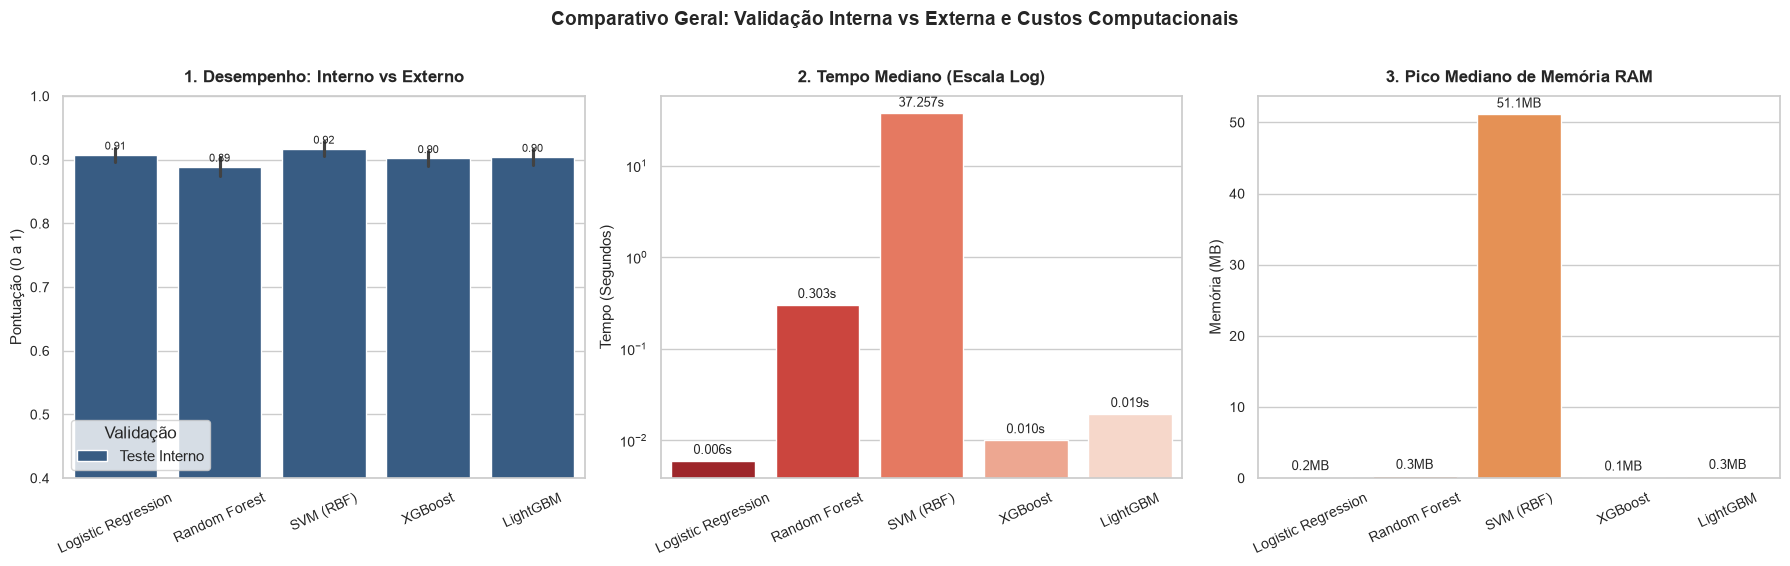

In [9]:
df_results = pd.DataFrame(results)

timestamp = datetime.datetime.now().strftime("%d-%m-%Y_%H-%M-%S")
filename = f"results/results_{timestamp}.csv"

df_results.to_csv(filename, index=False, encoding="utf-8")

print(f"Resultados guardados com sucesso no arquivo: {filename}")

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

df_melted = df_results.melt(
    id_vars=["Model", "Set"],
    value_vars=["Accuracy", "F1-Score"],
    var_name="Métrica",
    value_name="Pontuação"
)

sns.barplot(
    data=df_melted,
    x="Model",
    y="Pontuação",
    hue="Set",
    ax=axes[0],
    palette=["#2b5c8f", "#d95f02"]
)
axes[0].set_title("1. Desempenho: Interno vs Externo", fontweight="bold", pad=10)
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel("Pontuação (0 a 1)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title="Validação", loc="lower left")

for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                         textcoords='offset points')

sns.barplot(
    data=df_results[df_results["Set"] == "Teste Interno"],
    x="Model",
    y="Median_Time_Sec",
    ax=axes[1],
    palette="Reds_r"
)
axes[1].set_title("2. Tempo Mediano (Escala Log)", fontweight="bold", pad=10)
axes[1].set_ylabel("Tempo (Segundos)")
axes[1].set_xlabel("")
axes[1].set_yscale("log")
axes[1].tick_params(axis='x', rotation=25)

for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].annotate(f"{h:.3f}s", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points')

sns.barplot(
    data=df_results[df_results["Set"] == "Teste Interno"],
    x="Model",
    y="Median_Memory_MB",
    ax=axes[2],
    palette="Oranges_r"
)
axes[2].set_title("3. Pico Mediano de Memória RAM", fontweight="bold", pad=10)
axes[2].set_ylabel("Memória (MB)")
axes[2].set_xlabel("")
axes[2].tick_params(axis='x', rotation=25)

for p in axes[2].patches:
    h = p.get_height()
    if h > 0:
        axes[2].annotate(f"{h:.1f}MB", (p.get_x() + p.get_width() / 2., h),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                         textcoords='offset points')

plt.suptitle("Comparativo Geral: Validação Interna vs Externa e Custos Computacionais", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

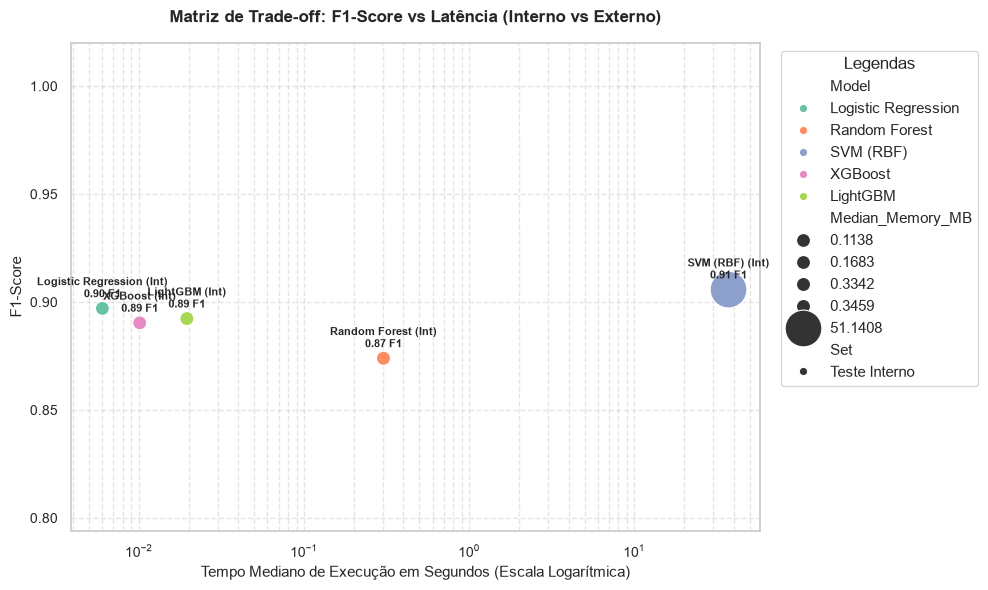

In [10]:
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_results,
    x="Median_Time_Sec",
    y="F1-Score",
    hue="Model",
    style="Set",
    size="Median_Memory_MB",
    sizes=(100, 700),
    palette="Set2"
)

plt.xscale("log")
plt.title("Matriz de Trade-off: F1-Score vs Latência (Interno vs Externo)", fontweight="bold", pad=15)
plt.xlabel("Tempo Mediano de Execução em Segundos (Escala Logarítmica)")
plt.ylabel("F1-Score")
plt.grid(True, which="both", ls="--", alpha=0.5)

for _, row in df_results.iterrows():
    prefix = "Int" if row["Set"] == "Teste Interno" else "Ext"
    plt.annotate(
        f"{row['Model']} ({prefix})\n{row['F1-Score']:.2f} F1",
        (row["Median_Time_Sec"], row["F1-Score"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8,
        weight="bold"
    )

plt.ylim(df_results["F1-Score"].min() - 0.08, 1.02)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Legendas")
plt.tight_layout()
plt.show()

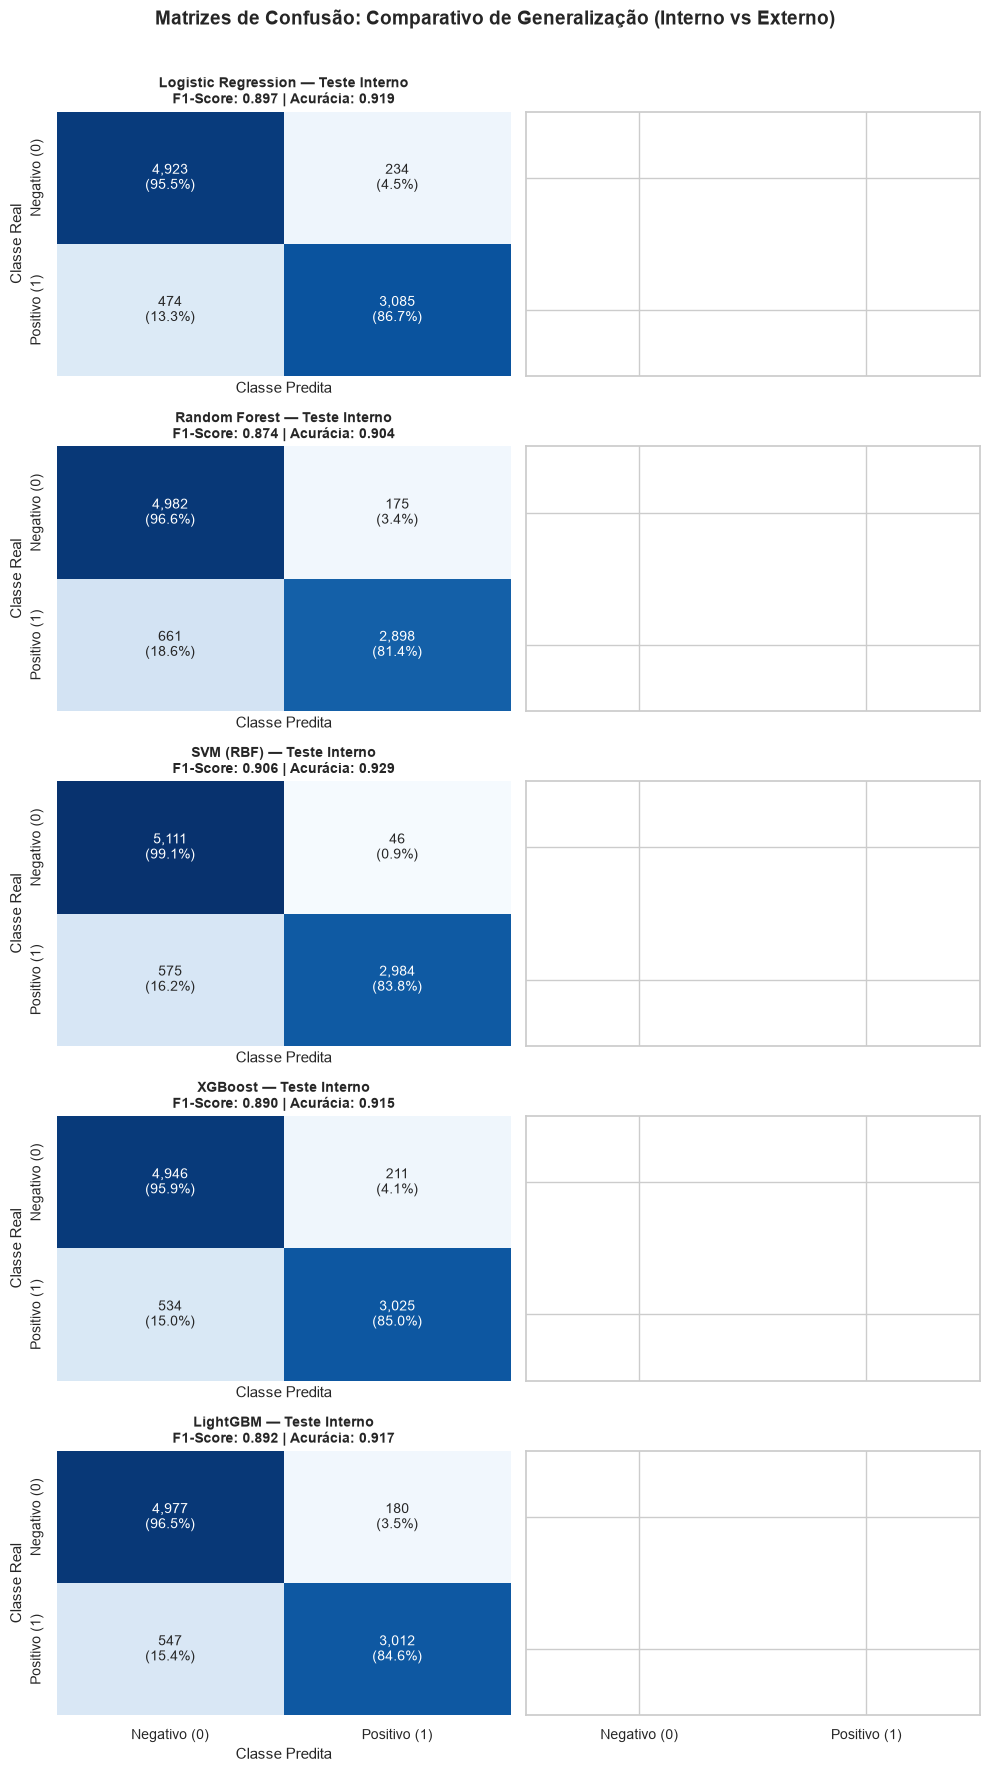

In [11]:
models = df_results["Model"].unique()
fig, axes = plt.subplots(len(models), 2, figsize=(10, 3.5 * len(models)), sharex=True, sharey=True)

for idx, model in enumerate(models):
    for jdx, set_name in enumerate(["Teste Interno", "Teste Externo"]):
        ax = axes[idx, jdx]
        sub_df = df_results[(df_results["Model"] == model) & (df_results["Set"] == set_name)]

        if not sub_df.empty:
            row = sub_df.iloc[0]
            cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
            cm_perc = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

            labels = [f"{val:,}\n({perc:.1%})" for val, perc in zip(cm.flatten(), cm_perc.flatten())]
            labels = np.array(labels).reshape(2, 2)

            sns.heatmap(
                cm_perc,
                annot=labels,
                fmt="",
                cmap="Blues" if set_name == "Teste Interno" else "Oranges",
                ax=ax,
                cbar=False,
                vmin=0,
                vmax=1,
                xticklabels=["Negativo (0)", "Positivo (1)"],
                yticklabels=["Negativo (0)", "Positivo (1)"]
            )
            ax.set_title(f"{model} — {set_name}\nF1-Score: {row['F1-Score']:.3f} | Acurácia: {row['Accuracy']:.3f}", fontsize=10, fontweight="bold")
            ax.set_xlabel("Classe Predita")
            ax.set_ylabel("Classe Real")

plt.suptitle("Matrizes de Confusão: Comparativo de Generalização (Interno vs Externo)", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()